In [1]:
import pandas as pd
import numpy as np

In [2]:
import tensorflow as tf
import keras 

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen= ImageDataGenerator(rescale=1./255)

In [5]:
train_generator= train_datagen.flow_from_directory(
    r"D:\Data Science\Campusx\Cats vs Dogs\Train",
    target_size= (256,256),
    batch_size= 16,
    class_mode= "binary"
)

Found 791 images belonging to 2 classes.


In [6]:
test_generator= test_datagen.flow_from_directory(
    r"D:\Data Science\Campusx\Cats vs Dogs\Test",
    target_size= (256,256),
    batch_size= 16,
    class_mode= "binary"
)

Found 209 images belonging to 2 classes.


In [7]:
from keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.regularizers import L2
from keras.callbacks import EarlyStopping

In [ ]:
model= Sequential([
    Input(shape=(256,256,3)),
    Conv2D(32, kernel_size=(3,3), padding= "valid", strides= (1,1), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2, padding="valid"),

    Conv2D(64, kernel_size=(3,3), padding="valid", strides= (1,1), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides= 2, padding="valid"),
    
    Flatten(),
    Dense(128, activation="relu", kernel_regularizer=L2(0.001)),
    Dense(64, activation="relu", kernel_regularizer=L2(0.001)),
    Dense(32, activation="relu", kernel_regularizer=L2(0.001)),
    Dropout(0.4),
    Dense(8, activation="relu", kernel_regularizer=L2(0.001)),
    Dense(4, activation="relu", kernel_regularizer=L2(0.001)),
    Dense(1, activation="sigmoid", kernel_regularizer=L2(0.001)),
])

In [9]:
model.compile(
    optimizer="Adam",
    loss= "binary_crossentropy",
    metrics= ["accuracy"]
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
callback= EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=2,
    mode="auto",
    restore_best_weights=True,
    baseline=None,
    verbose=1
)

In [25]:
history= model.fit(
    train_generator,
    # steps_per_epoch= 2000//16,
    epochs= 25,
    validation_data= test_generator,
    # validation_steps= 800//16,
    callbacks=callback
)

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 782ms/step - accuracy: 0.6018 - loss: 2.5723 - val_accuracy: 0.6316 - val_loss: 2.7330
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 805ms/step - accuracy: 0.6675 - loss: 2.4439 - val_accuracy: 0.7177 - val_loss: 2.0820
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 800ms/step - accuracy: 0.7307 - loss: 1.8308 - val_accuracy: 0.7799 - val_loss: 1.5992
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 806ms/step - accuracy: 0.7560 - loss: 1.4352 - val_accuracy: 0.8325 - val_loss: 1.2755
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 804ms/step - accuracy: 0.7661 - loss: 1.2114 - val_accuracy: 0.8086 - val_loss: 1.0972
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 808ms/step - accuracy: 0.7901 - loss: 1.0416 - val_accuracy: 0.7751 - val_loss: 1.0301
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 736ms/step - accuracy: 0.8217 - loss: 0.9491 - val_accuracy: 0.6364 - val_loss: 1.2084
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 497ms/step - accuracy: 0.8293 - loss: 0.8298 - val_accu

In [21]:
import matplotlib.pyplot as plt

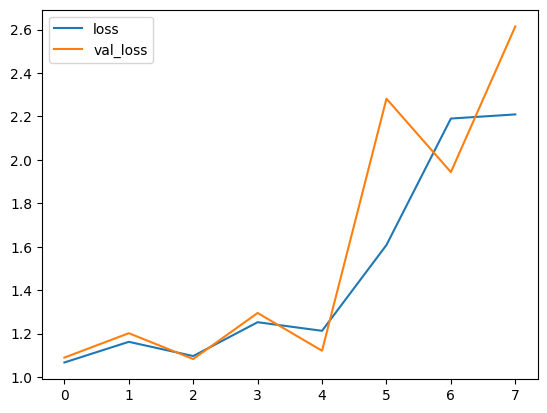

In [22]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()

In [27]:
predictons = model.predict(test_generator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step


In [29]:
predictons= predictons.ravel()

In [30]:
def results(predictions):
    for i in range(len(predictions)):
        if predictions[i]>=0.5:
            predictions[i]=1
        else:
            predictions[i]=0
    return predictions

In [31]:
predictions= results(predictons)

In [33]:
test_loss, test_acc= model.evaluate(test_generator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.8947 - loss: 0.7006


In [34]:
print(f"The loss is {test_loss}")
print(f"Accuracy of model is {test_acc*100}")

The loss is 0.7006323933601379
Accuracy of model is 89.47368264198303
